# Social Media Processing

This notebook shows how to use HuggingFace's package to import and train regression models to assess humor rating in social media posts in English (SemEval2021: HaHackathon: Detecting and Rating Humor and Offense https://competitions.codalab.org/competitions/27446, **Task-1b**).

Detection of humour, especially in social media posts, poses a linguistic challenge to NLP, due to the noise, figurative language, contextuality and subjectivity. You will hence try different methods to address those challenges such as preprocessing, data augmentation, ensembling and multi-task learning.

We will download and unzip the data from here: http://smash.inf.ed.ac.uk/hahackathon_data/hahackathon_data.zip.


We recommend you to do this lab on a Colab GPU provided by Google.

In [ ]:
!wget http://smash.inf.ed.ac.uk/hahackathon_data/hahackathon_data.zip
!unzip '/content/hahackathon_data.zip' -x __MACOSX/*

--2025-03-15 10:55:42--  http://smash.inf.ed.ac.uk/hahackathon_data/hahackathon_data.zip
Resolving smash.inf.ed.ac.uk (smash.inf.ed.ac.uk)... 129.215.10.97
Connecting to smash.inf.ed.ac.uk (smash.inf.ed.ac.uk)|129.215.10.97|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 571603 (558K) [application/zip]
Saving to: ‘hahackathon_data.zip’

hahackathon_data.zi 100%[===================>] 558.21K   676KB/s    in 0.8s    

2025-03-15 10:55:44 (676 KB/s) - ‘hahackathon_data.zip’ saved [571603/571603]

Archive:  /content/hahackathon_data.zip
   creating: hahackathon data/
  inflating: hahackathon data/.DS_Store  
  inflating: hahackathon data/test.csv  
  inflating: hahackathon data/dev.csv  
  inflating: hahackathon data/train.csv  


First, we need to install Hugging Face [transformers](https://huggingface.co/transformers/index.html) and [Sentence piece Tokenizers](https://github.com/google/sentencepiece), as well as some helper libraries, with the following commands.

In [ ]:
!pip install -q transformers
!pip install -q sentencepiece
!pip install -q  ipywidgets
!jupyter nbextension enable --py widgetsnbextension

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.0 MB/s eta 0:00:00
Enabling notebook extension jupyter-js-widgets/extension...
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json
Paths used for configuration of notebook: 
    	
      - Validating: OK
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from transformers import DistilBertTokenizer, DistilBertModel, AdamW
from torch.utils.data import Dataset, DataLoader

We define the fix seed method to be able to introduce variety into ensembling models.

In [ ]:
# Set random seed for reproducibility
def set_random_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_random_seed()

## Regression with BERT

We will use the [DistilBert](https://arxiv.org/abs/1910.01108v4) model and its Tokeniser following the preprocessing code from Lab on Aspect-Based Sentiment Analysis.

In [ ]:
import tqdm

# Constants
PAD_LENGTH = 128
BATCH_SIZE = 256
EPOCHS = 5
bert_model = 'distilbert-base-uncased'

# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(bert_model, do_lower_case=True, max_length=PAD_LENGTH, padding='max_length', truncation=True)

def tokenize(sentences, tokenizer, pad_length=PAD_LENGTH, pad_to_max_length=True):
    if type(sentences) == str:
        inputs = tokenizer.encode_plus(sentences, add_special_tokens=True, max_length=pad_length, pad_to_max_length=pad_to_max_length,
                                             return_attention_mask=True, return_token_type_ids=True)
        return inputs['input_ids'], inputs['attention_mask'], inputs['token_type_ids']

    input_ids, input_masks, input_segments = [],[],[]
    for sentence in sentences:
        inputs = tokenizer.encode_plus(sentence, add_special_tokens=True, max_length=pad_length, pad_to_max_length=pad_to_max_length,
                                             return_attention_mask=True, return_token_type_ids=True)
        input_ids.append(inputs['input_ids'])
        input_masks.append(inputs['attention_mask'])
        input_segments.append(inputs['token_type_ids'])
    return input_ids, input_masks, input_segments


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Let's read the data using Pandas.

In [ ]:
import pandas as pd

# Load data with only the necessary columns
train_df = pd.read_csv('hahackathon data/train.csv', usecols = ['text','humor_rating','offense_rating'])
dev_df = pd.read_csv('hahackathon data/dev.csv', usecols = ['text','humor_rating','offense_rating'])
test_df = pd.read_csv('hahackathon data/test.csv', usecols = ['text','humor_rating','offense_rating'])

# Drop the Nans
train_df = train_df.dropna()
dev_df = dev_df.dropna()
test_df = test_df.dropna()

Let's check a couple of examples.

In [ ]:
train_df

,text,humor_rating,offense_rating
0,TENNESSEE: We're the best state. Nobody even c...,2.42,0.20
1,A man inserted an advertisement in the classif...,2.50,1.10
2,How many men does it take to open a can of bee...,1.95,2.40
3,Told my mom I hit 1200 Twitter followers. She ...,2.11,0.00
4,Roses are dead. Love is fake. Weddings are bas...,2.78,0.10
...,...,...,...
7991,"Sins are like viruses, it's better you keep th...",2.13,0.10
7993,My daughter wanted a Cinderella themed birthda...,3.70,0.00
7996,Why are aspirins white? Because they work sorry,1.33,3.85
7997,"Today, we Americans celebrate our independence...",2.55,0.00


In [ ]:
# Get the post text
train_examples_list = train_df['text'].tolist()
dev_examples_list = dev_df['text'].tolist()
test_examples_list = test_df['text'].tolist()

# Get the humour rating for the regression task (we normalise, the values are between 0 and 5)
train_targets_list = (train_df['humor_rating']/5).tolist()
dev_targets_list = (dev_df['humor_rating']/5).tolist()
test_targets_list = (test_df['humor_rating']/5).tolist()

In [ ]:
def get_bert_inputs(examples_list, targets):
  input_ids=list()
  attention_masks=list()

  bert_inp=tokenize(examples_list, tokenizer)
  input_ids = bert_inp[0]
  attention_masks = bert_inp[1]

  return input_ids, attention_masks, targets

train_input_ids, train_attention_masks, train_targets = get_bert_inputs(train_examples_list, train_targets_list)
dev_input_ids, dev_attention_masks, dev_targets = get_bert_inputs(dev_examples_list, dev_targets_list)
test_input_ids, test_attention_masks, test_targets = get_bert_inputs(test_examples_list, test_targets_list)


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2681: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


**Task 1: Build a neural bag of words model using DistilBERT embeddings and the sigmoid activation on the output layer for the regression task.**

Investigate its performance using the Mean Squared Error (MSE) metric. We will use this metric as the loss function as well. We will also use the Adam optimiser with `learning_rate=2e-5`. This code is already provided.

*Hint*: You can reuse the code from Lab on Aspect-Based Sentiment Analysis (Model 2).

In [ ]:
class GlobalAveragePooling1DMasked(nn.Module):
    def forward(self, x, mask):
        mask = mask.unsqueeze(-1).float()
        x = x * mask
        sum_x = torch.sum(x, dim=1)
        sum_mask = torch.sum(mask, dim=1)
        return sum_x / sum_mask

# Define model
class BERTRegressionModel(nn.Module):

    def __init__(self, pad_length=128):
        super(BERTRegressionModel, self).__init__()
        self.bert = DistilBertModel.from_pretrained(bert_model)
        self.global_avg_pool = GlobalAveragePooling1DMasked()
        self.hidden_layer = nn.Linear(self.bert.config.hidden_size, 16)
        self.activation = nn.Sigmoid()
        self.output_reg = nn.Linear(16, 1)

    def forward(self, input_ids, attention_mask):
        """
        Task 1

        Begin
        """
        #1. get the bert outputs
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        #2. pooling over the valid tkns
        pooled = self.global_avg_pool(bert_output.last_hidden_state, attention_mask)

        #3. pass through hidden layer (sigmoid activ.)
        hidden = self.activation(self.hidden_layer(pooled))

        #4. o/p layer (sigmoid activ.)
        out_reg = self.activation(self.output_reg(hidden))

        """
        End Task 1
        """

        return out_reg


model = BERTRegressionModel()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
print(model)

BERTRegressionModel(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Li

In [ ]:
# Dataset Class
class HumorDataset(Dataset):
    def __init__(self, input_ids, attention_masks, targets):
        self.input_ids = torch.tensor(input_ids)
        self.attention_masks = torch.tensor(attention_masks)
        self.targets = torch.tensor(targets)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'target': self.targets[idx].float()
        }

In [ ]:
# Training setup
def train_model(model, train_loader, val_loader, device, epochs=EPOCHS, lr=2e-5):
    model.train()
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch in tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['target'].to(device)
            outputs = model(input_ids, attention_mask)

            loss = loss_fn(outputs.squeeze(), targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                targets = batch['target'].to(device)
                outputs = model(input_ids, attention_mask)
                loss = loss_fn(outputs.squeeze(), targets)
                val_loss += loss.item()

        print(f"Train Loss: {train_loss / len(train_loader):.4f}, Val Loss: {val_loss / len(val_loader):.4f}")


We evaluate our model on the test set.

In [ ]:
# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Prepare DataLoader
train_dataset = HumorDataset(train_input_ids, train_attention_masks, train_targets)
dev_dataset = HumorDataset(dev_input_ids, dev_attention_masks, dev_targets)
test_dataset = HumorDataset(test_input_ids, test_attention_masks, test_targets)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Instantiate model and train
model = BERTRegressionModel()
train_model(model, train_loader, dev_loader, device)

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/5: 100%|██████████| 20/20 [00:41<00:00,  2.09s/it]


Train Loss: 0.0129, Val Loss: 0.0127


Epoch 2/5: 100%|██████████| 20/20 [00:41<00:00,  2.08s/it]


Train Loss: 0.0126, Val Loss: 0.0124


Epoch 3/5: 100%|██████████| 20/20 [00:42<00:00,  2.15s/it]


Train Loss: 0.0121, Val Loss: 0.0119


Epoch 4/5: 100%|██████████| 20/20 [00:42<00:00,  2.14s/it]


Train Loss: 0.0114, Val Loss: 0.0114


Epoch 5/5: 100%|██████████| 20/20 [00:42<00:00,  2.15s/it]


Train Loss: 0.0109, Val Loss: 0.0111


In [ ]:
from sklearn.metrics import mean_squared_error


# Evaluate the model
def evaluate_model(model, test_loader, device, multi_task=False):
    model.eval()
    model.to(device)
    loss_fn = nn.MSELoss()

    preds = []
    gt = []
    loss_list = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['target'].to(device)
            outputs = model(input_ids, attention_mask)
            #for multi_task setting we only evaluate the humor rating to make it inline with the other models.
            if multi_task:
              outputs = outputs[:,0]
              targets = targets[:,0].squeeze()
            preds.append(outputs.squeeze().cpu().numpy())
            gt.append(targets.cpu().numpy())
            loss_list.append(loss_fn(outputs.squeeze(), targets).cpu().numpy())

    preds = np.concatenate(preds)
    gt = np.concatenate(gt)

    mse = mean_squared_error(gt, preds)
    avg_loss = np.mean(loss_list)
    print(f'Test loss: {avg_loss:.4f}')
    print(f'Test Mean Squared Error: {mse:.4f}')
    return preds, gt

preds, test_targets = evaluate_model(model, test_loader, device)

Test loss: 0.0113
Test Mean Squared Error: 0.0116


Get the array of predictions here so that you can plot the outputs later.

## Predictive Distribution

We compute min, max and mean for the golden and predicted humour ratings.

In [ ]:
min(preds), max(preds), preds.mean()

(0.37325662, 0.55556697, 0.44613013)

In [ ]:
min(test_targets), max(test_targets), test_targets.mean()

(0.054, 0.684, 0.42383412)

<Axes: >

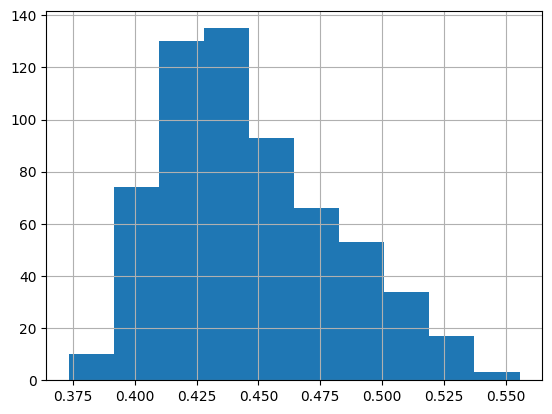

In [ ]:
pd.Series(preds).hist()

<Axes: >

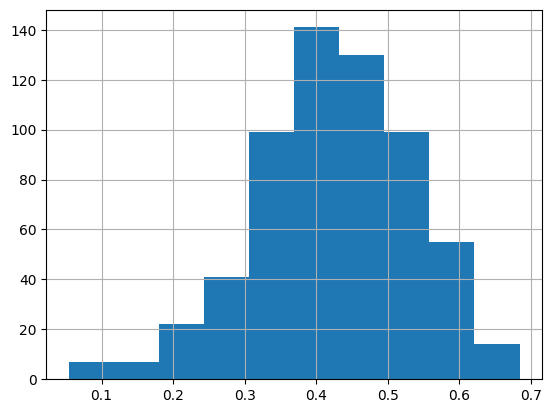

In [ ]:
pd.Series(test_targets).hist()

Next, we plot the true vs predicted humour grade for our model.

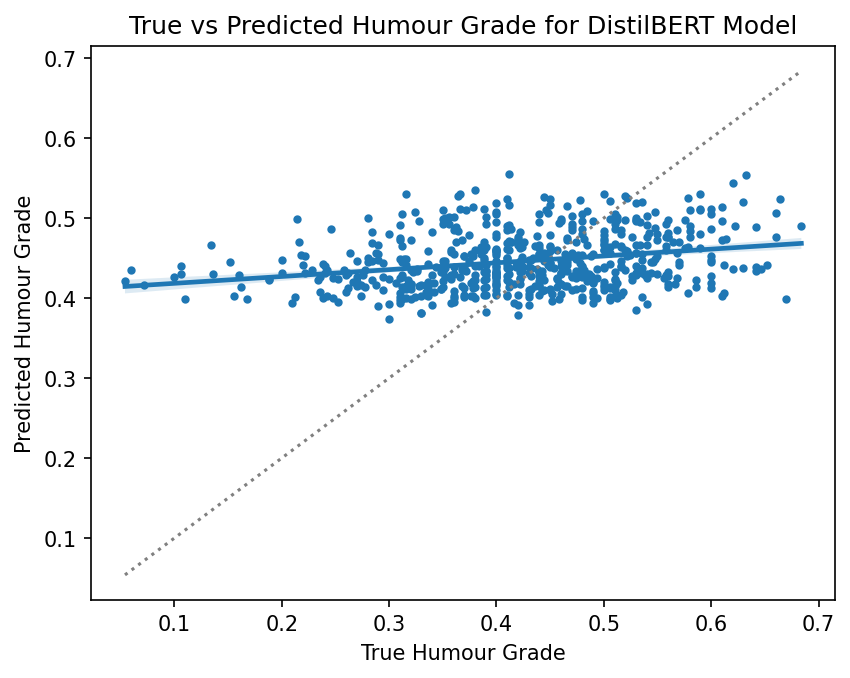

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
def get_pred_true_plot(preds, labels, title):
    limits = [labels.min(), labels.max()]
    fig, ax = plt.subplots()
    fig.set_dpi(150)
    ax.set_title(title)
    ax.scatter(labels, preds, marker='.')
    ax.plot(limits, limits, color="gray", linestyle=":")
    ax.set_xlabel('True Humour Grade')
    ax.set_ylabel('Predicted Humour Grade')
    sns.regplot(x=labels, y=preds, ax=ax, scatter_kws={"s": 5})
    plt.show()

get_pred_true_plot(preds, test_targets, 'True vs Predicted Humour Grade for DistilBERT Model')

Our regressor tends to smooth down the extreme rating values to make them closer to the mean.

# Feature Engineering & Data Augmentation

**Task 2: Preprocess the textual data with the Ekphrasis library following the standard pipeline https://github.com/cbaziotis/ekphrasis#text-pre-processing-pipeline. How does this affect the performance?**


*Hint*: You might not want to annotate terms in order to keep the same length of the input sentences (for this, do not use the parameter `annotate={"hashtag", "allcaps", "elongated", "repeated", 'emphasis', 'censored'}`).

<font color="red">How does this affect the performance?</font>

Model (a) (without pre-processing) achieves a test MSE of approx. 0.0116. Whereas,
Model (b) (with Ekphrasis preprocessing ) acheives a test MSE of approx. 0.0115. The differ-
ence between the two models is very small. This implies that both models have pretty much
the same performance. One reason for the small difference could be due the Ekphrasis pre-
processing technique not resulting in large gains for this dataset. More importantly, another
reason for the small difference could be due to the fact that DistilBERT already provides strong
language representations. Therefore, further pre-processing may not lead to reduced noise in
the data.

In [ ]:
!pip install -q ekphrasis
!pip3 install -q emoji==0.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.8/83.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from ekphrasis.classes.preprocessor import TextPreProcessor
from ekphrasis.classes.tokenizer import SocialTokenizer
from ekphrasis.dicts.emoticons import emoticons

In [ ]:
"""
Task 2

Begin
"""
# init. the ekphrasis text preprocessor
# using the given pipeline
text_processor = TextPreProcessor(
    # terms that will be normalized
    normalize=['url', 'email', 'percent', 'money', 'phone', 'user', 'time', 'date', 'number'],
    fix_html=True, # fix HTML tokens
    # corpus from which the word statistics are going to be used
    segmenter="twitter", # for word segmentation
    corrector="twitter", # for spell correction
    unpack_hashtags=True, # perform word segmentation on hashtags
    unpack_contractions=True,
    spell_correct_elong=False,
    tokenizer=SocialTokenizer(lowercase=True).tokenize,
    dicts=[emoticons]
)

"""
End Task 2
"""
new_train_examples_list = [" ".join(text_processor.pre_process_doc(example)) for example in train_examples_list]
new_dev_examples_list = [" ".join(text_processor.pre_process_doc(example)) for example in dev_examples_list]
new_test_examples_list = [" ".join(text_processor.pre_process_doc(example)) for example in test_examples_list]


/usr/local/lib/python3.11/dist-packages/ekphrasis/classes/tokenizer.py:225: FutureWarning: Possible nested set at position 2190
  self.tok = re.compile(r"({})".format("|".join(pipeline)))


Word statistics files not found!
Downloading... done!
Unpacking... done!
Reading twitter - 1grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/twitter/counts_1grams.txt
Reading twitter - 2grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/twitter/counts_2grams.txt


/usr/local/lib/python3.11/dist-packages/ekphrasis/classes/exmanager.py:14: FutureWarning: Possible nested set at position 42
  regexes = {k.lower(): re.compile(self.expressions[k]) for k, v in


Reading twitter - 1grams ...


In [ ]:
print("Original Text:", train_examples_list[0])
print("Preprocessed Text:", new_train_examples_list[0])

Original Text: TENNESSEE: We're the best state. Nobody even comes close. *Elevennessee walks into the room* TENNESSEE: Oh shit...
Preprocessed Text: tennessee : we are the best state . nobody even comes close . * elevennessee walks into the room * tennessee : oh shit . . .


In [ ]:
train_input_ids, train_attention_masks, train_targets = get_bert_inputs(new_train_examples_list, train_targets_list)
dev_input_ids, dev_attention_masks, dev_targets = get_bert_inputs(new_dev_examples_list, dev_targets_list)
test_input_ids, test_attention_masks, test_targets = get_bert_inputs(new_test_examples_list, test_targets_list)


# Prepare DataLoader
train_dataset = HumorDataset(train_input_ids, train_attention_masks, train_targets)
dev_dataset = HumorDataset(dev_input_ids, dev_attention_masks, dev_targets)
test_dataset = HumorDataset(test_input_ids, test_attention_masks, test_targets)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model = BERTRegressionModel()
train_model(model, train_loader, dev_loader, device)

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2681: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/5: 100%|██████████| 20/20 [00:42<00:00,  2.13s/it]


Train Loss: 0.0156, Val Loss: 0.0133


Epoch 2/5: 100%|██████████| 20/20 [00:43<00:00,  2.16s/it]


Train Loss: 0.0129, Val Loss: 0.0126


Epoch 3/5: 100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


Train Loss: 0.0124, Val Loss: 0.0122


Epoch 4/5: 100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


Train Loss: 0.0119, Val Loss: 0.0118


Epoch 5/5: 100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


Train Loss: 0.0114, Val Loss: 0.0115


In [ ]:
preds, test_targets = evaluate_model(model, test_loader, device)

Test loss: 0.0120
Test Mean Squared Error: 0.0123


Your results may be different depending on the implementation but typically special preprocessing does not drastically change the performance for this task.

**Task 3: Augment the training data twice by changing the original data via two methods from the Nlpaug (https://github.com/makcedward/nlpaug) library: (a) synonym replacement from WordNet; (b) deletion of random words. Comment on which method gives the best performance.**

*Hint*: Use the Synonym Augmenter and Random Word Augmenter (Delete word randomly) classes as follows:
```
aug = naw.SynonymAug(aug_src='wordnet')
augmented_text = aug.augment(text)

aug = naw.RandomWordAug()
augmented_text = aug.augment(text)
```





For more examples check https://github.com/makcedward/nlpaug/blob/master/example/textual_augmenter.ipynb

<font color="red">Comment on which method gives the best performance:</font>
Both models converge to the same Dev set MSE of 0.0111. How-
ever, there is a negligible difference seen in the Dev loss of 0.0108 (a) versus 0.0109 (b). The final MSE of both methods is the same, so the net effect of each strategy is very small. This minor impact from both data augmentation methods is understandable, since DistilBERT already captures most of the semantics. Thus, neither synonym replacement, nor word deletion will affect the model’s performance by a large margin. Nonetheless, from the results model (a) performed slightly better.

In [ ]:
!pip install nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.5 MB/s eta 0:00:00


In [ ]:
import nltk

# Download the required NLTK resource
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Get the data again to apply augmentation
train_examples_list = train_df['text'].tolist()
train_targets_list = (train_df['humor_rating']/5).tolist()

In [ ]:
import nlpaug.augmenter.word as naw

"""
Task 3

Begin
"""
# ---------------------------
# Experiment A. Synonym Replacement using WordNet
# ---------------------------
print("Experiment A. Synonym Replacement Augmentation")
# instantiate the augmenter for part A
synonym_aug = naw.SynonymAug(aug_src='wordnet')

#generate the augmented for ea. train sample
augmented_synonyms = [synonym_aug.augment(text) for text in train_examples_list]

# new train set = orig. train examples with the augmented_syn
train_examples_syn = train_examples_list + augmented_synonyms

#replicate for target (orig + augmented)
train_targets_syn = train_targets_list * 2

print("sample augmented (Synonym):", train_examples_syn[-2])

Experiment A. Synonym Replacement Augmentation
sample augmented (Synonym): ['Today, we Americans celebrate our independence from Britain while plan our escape to Canada.']


In [ ]:
train_input_ids_syn, train_attention_masks_syn, train_targets_syn = get_bert_inputs(train_examples_syn, train_targets_syn)
# DataLoader for experiment A
train_dataset_syn = HumorDataset(train_input_ids_syn, train_attention_masks_syn, train_targets_syn)
train_loader_syn = DataLoader(train_dataset_syn, batch_size=BATCH_SIZE, shuffle=True)

# training a new model on the synonym-augmented data
model_syn = BERTRegressionModel().to(device)
train_model(model_syn, train_loader_syn, dev_loader, device)

# evaluate the model on the dev set
preds_syn, dev_targets_syn = evaluate_model(model_syn, dev_loader, device)
print("Experiment A Dev Evaluation complete.\n")

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2681: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/5: 100%|██████████| 39/39 [01:24<00:00,  2.18s/it]


Train Loss: 0.0129, Val Loss: 0.0127


Epoch 2/5: 100%|██████████| 39/39 [01:25<00:00,  2.18s/it]


Train Loss: 0.0126, Val Loss: 0.0122


Epoch 3/5: 100%|██████████| 39/39 [01:25<00:00,  2.18s/it]


Train Loss: 0.0123, Val Loss: 0.0115


Epoch 4/5: 100%|██████████| 39/39 [01:25<00:00,  2.18s/it]


Train Loss: 0.0120, Val Loss: 0.0112


Epoch 5/5: 100%|██████████| 39/39 [01:25<00:00,  2.18s/it]


Train Loss: 0.0117, Val Loss: 0.0108
Test loss: 0.0108
Test Mean Squared Error: 0.0111
Experiment A Dev Evaluation complete.



In [ ]:
# ------------------
# Experiment B. random Word Deletion Augmentation
# ------------------
print("Experiment B. Random Word Deletion Augmentation")

# instantiate the augmenter for part B
random_del_aug = naw.RandomWordAug(action="delete")

#generate the augmented for ea. train sample
augmented_random_del = [random_del_aug.augment(text) for text in train_examples_list]

# new train set = orig. train examples with the augmented_random_del
train_examples_rand = train_examples_list + augmented_random_del

#replicate for target (orig + augmented)
train_targets_rand = train_targets_list * 2

print("Sample augmented (Random Deletion):", train_examples_rand[-2])

Experiment B. Random Word Deletion Augmentation
Sample augmented (Random Deletion): ['Today, we Americans celebrate our independence planning our to.']


In [ ]:
train_input_ids_rand, train_attention_masks_rand, train_targets_rand = get_bert_inputs(train_examples_rand, train_targets_rand)

# DataLoader for experiment A
train_dataset_rand = HumorDataset(train_input_ids_rand, train_attention_masks_rand, train_targets_rand)
train_loader_rand = DataLoader(train_dataset_rand, batch_size=BATCH_SIZE, shuffle=True)

# training a new model on the synonym-augmented data
model_rand = BERTRegressionModel().to(device)
train_model(model_rand, train_loader_rand, dev_loader, device)

# evaluate the model on the dev set
preds_rand, dev_targets_rand = evaluate_model(model_rand, dev_loader, device)
print("Experiment B Dev Evaluation complete.\n")


"""
End Task 3
"""

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2681: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/5: 100%|██████████| 39/39 [01:25<00:00,  2.19s/it]


Train Loss: 0.0148, Val Loss: 0.0129


Epoch 2/5: 100%|██████████| 39/39 [01:25<00:00,  2.18s/it]


Train Loss: 0.0127, Val Loss: 0.0122


Epoch 3/5: 100%|██████████| 39/39 [01:25<00:00,  2.19s/it]


...

Epoch 4/5: 100%|██████████| 39/39 [01:25<00:00,  2.18s/it]


Train Loss: 0.0121, Val Loss: 0.0113


Epoch 5/5: 100%|██████████| 39/39 [01:25<00:00,  2.18s/it]


Train Loss: 0.0118, Val Loss: 0.0109
Test loss: 0.0109
Test Mean Squared Error: 0.0111
Experiment B Dev Evaluation complete.



'\nEnd Task 3\n'

We have now augmented the original data twice:

In [ ]:
print("Experiment A:")
print("original training examples:", len(train_examples_list))
print("After synonym augmentation:", len(train_examples_syn))


print("\nExperiment B:")
print("original training examples:", len(train_examples_list))
print("After random word deletion augmentation:", len(train_examples_rand))

Experiment A:
original training examples: 4932
After synonym augmentation: 9864

Experiment B:
original training examples: 4932
After random word deletion augmentation: 9864


Your results may be different depending on the implementation but typically there are no drastic differences between the augmentation setups.

# Ensembled BERT Model

In this section you will train and evaluate an **ensemble** of BERT models.

We define the hyperparameters, including the number of models we want to ensemble (RERUNS=3, i.e., 3 models).

**Task 4: Train three DistilBERT models, get their predictions on the test set, take the mean of those predictions and evaluate this ensembled prediction. Comment on the resulting performance.**

We create three models in a loop, set a new random seed before creating each of them (`set_random_seed(seed=random.randint(0, 500))`) and accumulate predictions per model in a list.

<font color="red">
Comment on the resulting performance:
</font>
the single model achieved a test MSE of 0.0116 and the three-model
ensemble achieved a test MSE of 0.0120. Despite the fact that the ensembled results should show improved performance over the single model, they do not. From the obeserved results, we can see that the final scores are relatively close. This implies that the baseline single model is already robust enough. Therefore, leaving a small gap for an ensemble to further improve the performance


In [ ]:
# Get the train data again to avoid any confusion
train_examples_list = train_df['text'].tolist()
train_targets_list = (train_df['humor_rating']/5).tolist()

train_input_ids, train_attention_masks, train_targets = get_bert_inputs(train_examples_list, train_targets_list)

# Prepare DataLoader
train_dataset = HumorDataset(train_input_ids, train_attention_masks, train_targets)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2681: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [ ]:
RERUNS = 3
# We may save each model to a list
# trained_models = list()
# We save the predictions of each model to the list
all_model_preds = list()


for i in range(RERUNS):

  set_random_seed(seed=random.randint(0, 500)) #sets diversity

  """
  Task 4

  Begin
  """
  #1. instantiate model on non-augmented data
  model = BERTRegressionModel().to(device)

  #2.train model on orig train loader
  train_model(model, train_loader, dev_loader, device)

  #3. eval the model
  preds, _ = evaluate_model(model, test_loader, device)

  #4. save the preds
  all_model_preds.append(preds)

  """
  End Task 4
  """



/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/5: 100%|██████████| 20/20 [00:41<00:00,  2.08s/it]


Train Loss: 0.0160, Val Loss: 0.0134


Epoch 2/5: 100%|██████████| 20/20 [00:43<00:00,  2.16s/it]


Train Loss: 0.0128, Val Loss: 0.0127


Epoch 3/5: 100%|██████████| 20/20 [00:42<00:00,  2.15s/it]


...

Train Loss: 0.0124, Val Loss: 0.0123


Epoch 4/5: 100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


Train Loss: 0.0120, Val Loss: 0.0119


Epoch 5/5: 100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


Train Loss: 0.0115, Val Loss: 0.0115
Test loss: 0.0117
Test Mean Squared Error: 0.0120


In [ ]:
from sklearn.metrics import classification_report, mean_squared_error

mean_preds = np.mean(np.array(all_model_preds), axis=0)
ensemble_mse = mean_squared_error(test_targets, mean_preds)

print('Ensemble Test MSE : {:.4f}'.format(ensemble_mse))

Ensemble Test MSE : 0.0120


Your results may be different depending on the implementation but typically ensembling slightly improves the performance for this task.

# Multi-task Learning with BERT

**Task 5: Train a multi-task (MTL) model with the additional regression task of predicting the offense rating. The code to fetch these data is provided below. Comment on the resulting performance for the two models (single-task from task 1 and MTL).**


*Hint*: The MTL model will have two identical output layers (one for predicting humour rating, the other to predict offense rating). The layers need to be concatenated before applying the loss fuctions.

<font color="red">Comment on the resulting performance for the two models (single-task from task 1 and MTL): </font>
<font color="white">

First, for a fair comparison, the MSE was calculated only for the extracted humour predictions (first output of the multi-model). Since the output of the single model is based on humour predictions and not offense predictions. Second, from the results we can see that the single-task model (from Task 1) achieved a Test MSE of approximately 0.0111 on the test set. In comparison, the multi-task model achieved a slightly higher Test MSE of 0.0119 for humor prediction.
One reason that the multi-model did not perform better than the single model could be because the model has a limited hidden layer of 16 neurons. This suggests that there might not be enough capacity for the multi-model to capture the features for both tasks (humour and
offense). This shared resource might have led the model to have a slight drop in the accuracy of humour prediction.
Another reason for no improvement over the baseline (task 1) could be due to the fact that the multi-model humour MSE value is already close in value to the task 1 value, which implies that the auxiliary task does not provide a clear advantage, but rather similar results. </font>






In [ ]:
import gc
if 'model' in locals():
  del model
gc.collect()
with torch.no_grad():
    torch.cuda.empty_cache()

In [ ]:
set_random_seed()

class BertMultitaskModel(nn.Module):
  """
  Task 5
  Begin
  """

  def __init__(self, pad_length=128):
    super(BertMultitaskModel, self).__init__()

    # DistilBert model
    self.bert = DistilBertModel.from_pretrained(bert_model)

    # pooling
    self.global_avg_pool = GlobalAveragePooling1DMasked()

    #
    self.hidden_layer = nn.Linear(self.bert.config.hidden_size, 16)

    # sigmoid activ.
    self.activation = nn.Sigmoid()

    # two separate linear layers:
    self.output_reg1 = nn.Linear(16, 1)  # for humor rating

    self.output_reg2 = nn.Linear(16, 1)  # for offense rating


  def forward(self, input_ids, attention_mask):
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    pooled = self.global_avg_pool(outputs.last_hidden_state, attention_mask)
    hidden = self.activation(self.hidden_layer(pooled))
    out_reg1 = self.activation(self.output_reg1(hidden)) # humor pred
    out_reg2 = self.activation(self.output_reg2(hidden)) # offense pred

    # Concatenate outputs
    return torch.cat([out_reg1, out_reg2], dim=1)

  """
  End Task 5
  """

In [ ]:
model = BertMultitaskModel(pad_length=PAD_LENGTH).to(device)

In [ ]:
train_examples_list = train_df['text'].tolist()
train_targets_list = (train_df['humor_rating']/5).tolist()

train_input_ids, train_attention_masks, train_targets = get_bert_inputs(train_examples_list, train_targets_list)

# Get the offense ratings for the second regression task (we normalise them as well)
train_targets2_list = (train_df['offense_rating']/5).tolist()
dev_targets2_list = (dev_df['offense_rating']/5).tolist()
test_targets2_list = (test_df['offense_rating']/5).tolist()

train_targets2 = np.array(train_targets2_list)
dev_targets2 = np.array(dev_targets2_list)
test_targets2 = np.array(test_targets2_list)

# Prepare DataLoader
train_targets_mix = [[i[0],i[1]] for i in zip(train_targets,train_targets2)]
train_dataset = HumorDataset(train_input_ids, train_attention_masks, train_targets_mix)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_targets_mix = [[i[0],i[1]] for i in zip(dev_targets,dev_targets2)]
dev_dataset = HumorDataset(dev_input_ids, dev_attention_masks, dev_targets_mix)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)
test_targets_mix = [[i[0],i[1]] for i in zip(test_targets,test_targets2)]
test_dataset = HumorDataset(test_input_ids, test_attention_masks, test_targets_mix)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2681: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [ ]:
# Instantiate model and train
train_model(model, train_loader, dev_loader, device)

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/5: 100%|██████████| 20/20 [00:41<00:00,  2.08s/it]


Train Loss: 0.0956, Val Loss: 0.0697


Epoch 2/5: 100%|██████████| 20/20 [00:42<00:00,  2.15s/it]


Train Loss: 0.0566, Val Loss: 0.0547


Epoch 3/5: 100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


Train Loss: 0.0479, Val Loss: 0.0516


Epoch 4/5: 100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


Train Loss: 0.0455, Val Loss: 0.0504


Epoch 5/5: 100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


Train Loss: 0.0443, Val Loss: 0.0497


In [ ]:
preds_dev, dev_targets_eval = evaluate_model(model, dev_loader, device, multi_task=True)
print("Multi-task Dev Evaluation complete.\n\n")

preds_test, test_targets = evaluate_model(model, test_loader, device, multi_task=True)
print("Multi-task Test Evaluation complete.\n")

Test loss: 0.0140
Test Mean Squared Error: 0.0143
Multi-task Dev Evaluation complete.


Test loss: 0.0116
Test Mean Squared Error: 0.0119
Multi-task Test Evaluation complete.



Your results may be different depending on the implementation but typically MTL slightly improves the performance over the single-task model trained in similar conditions.